**Author:** Ashutosh Jayant  
**Project:** India State Competitiveness Index (ISCI)

# 10 - State Clustering

**This notebook answers one research question.**

**Research Question:** Can states be grouped into similar types using their scores?

Clustering does not use geography, population or income. It groups states only by their
scores on the two measured parts: Factor Conditions and Related & Supporting Industries.

## Setup

Load the two part-scores for the 33 ranked states, and put both on the same scale so one
does not dominate the grouping.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

fig_dir = root / "version2" / "figures" / "clusters"
fig_dir.mkdir(parents=True, exist_ok=True)
reports_dir = root / "version2" / "reports"

index = pd.read_csv(root / "results" / "competitiveness_index.csv", index_col=0)
dimensions = pd.read_csv(root / "results" / "dimension_scores.csv", index_col=0)
ranked = index[index["Rank"].notna()].index

X = dimensions.loc[ranked, ["factor_conditions", "related_supporting"]]
Xs = StandardScaler().fit_transform(X)   # put both parts on the same scale

sns.set_theme(style="whitegrid")
print("states to cluster:", len(X))
print(X.describe().round(3).loc[["mean", "std", "min", "max"]].to_string())

states to cluster: 33
      factor_conditions  related_supporting
mean              0.415               0.371
std               0.083               0.207
min               0.261               0.072
max               0.565               0.829


## Choose the number of groups

Try 2 to 5 groups. Compare them two ways: inertia (how tight the groups are, lower is
tighter) and the silhouette score (how well separated they are, from -1 to 1, higher is
better).

In [2]:
rows = []
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xs)
    rows.append({"K": k,
                 "inertia": round(km.inertia_, 2),
                 "silhouette": round(silhouette_score(Xs, km.labels_), 3)})
print(pd.DataFrame(rows).to_string(index=False))

 K  inertia  silhouette
 2    28.19       0.461
 3    18.78       0.410
 4    14.17       0.361
 5     9.84       0.398


### Why three groups

The silhouette score is highest at two groups (0.46), but two groups only split states
into strong and weak. That hides an interesting middle type: states that are strong on
basic conditions but weak on industry.

Three groups still has a good silhouette score (0.41), and the biggest drop in inertia is
from two groups to three. Four and five groups score lower and split states into smaller
pieces that are harder to name.

So we choose three groups. It is the smallest number that shows a clear third type.

## Make the groups and name them

Make three groups. Look at the average scores of each group. Then give each group a name
that describes its scores. The names come from the data, not decided in advance.

In [3]:
km = KMeans(n_clusters=3, random_state=42, n_init=10).fit(Xs)
clusters = pd.Series(km.labels_, index=ranked, name="cluster")

profile = X.groupby(clusters).mean()
profile["total"] = profile.sum(axis=1)

weak = profile["total"].idxmin()
others = [c for c in profile.index if c != weak]
industry = max(others, key=lambda c: profile.loc[c, "related_supporting"])
conditions = [c for c in others if c != industry][0]

names = {
    industry: "Strong on both parts",
    conditions: "Strong basic conditions, weaker industry",
    weak: "Weak on both parts",
}
cluster_name = clusters.map(names)

order = ["Strong on both parts", "Strong basic conditions, weaker industry", "Weak on both parts"]
for nm in order:
    members = list(cluster_name[cluster_name == nm].index)
    print(f"{nm} ({len(members)}):")
    print(" ", ", ".join(members))
    print()

Strong on both parts (12):
  Goa, Tamil Nadu, Gujarat, Puducherry, Telangana, Andhra Pradesh, Punjab, Maharashtra, Himachal Pradesh, Haryana, Uttarakhand, Odisha

Strong basic conditions, weaker industry (6):
  Karnataka, Delhi, Kerala, West Bengal, Chandigarh, Mizoram

Weak on both parts (15):
  Sikkim, Rajasthan, Assam, Jharkhand, Chhattisgarh, Madhya Pradesh, Tripura, Jammu & Kashmir, Uttar Pradesh, Manipur, Andaman & Nicobar Islands, Bihar, Meghalaya, Nagaland, Arunachal Pradesh



## Group summary

One row per group: how many states, the average basic-inputs score, the average industry
score, the average overall score, and the average rank.

In [4]:
summary = pd.DataFrame({
    "states": cluster_name.value_counts(),
    "avg_FC": X.groupby(cluster_name)["factor_conditions"].mean().round(3),
    "avg_Industry": X.groupby(cluster_name)["related_supporting"].mean().round(3),
    "avg_score": index.loc[ranked, "competitiveness_score"].groupby(cluster_name).mean().round(3),
    "avg_rank": index.loc[ranked, "Rank"].groupby(cluster_name).mean().round(1),
}).reindex(order)
print(summary.to_string())

                                          states  avg_FC  avg_Industry  avg_score  avg_rank
cluster                                                                                    
Strong on both parts                          12   0.475         0.602      0.523       6.7
Strong basic conditions, weaker industry       6   0.482         0.265      0.400      16.5
Weak on both parts                            15   0.340         0.228      0.295      25.5


## Cluster scatter plot

Plot every state by its two part-scores. X is Factor Conditions, Y is industry. Colour
shows the group, and each dot is labelled with the state.

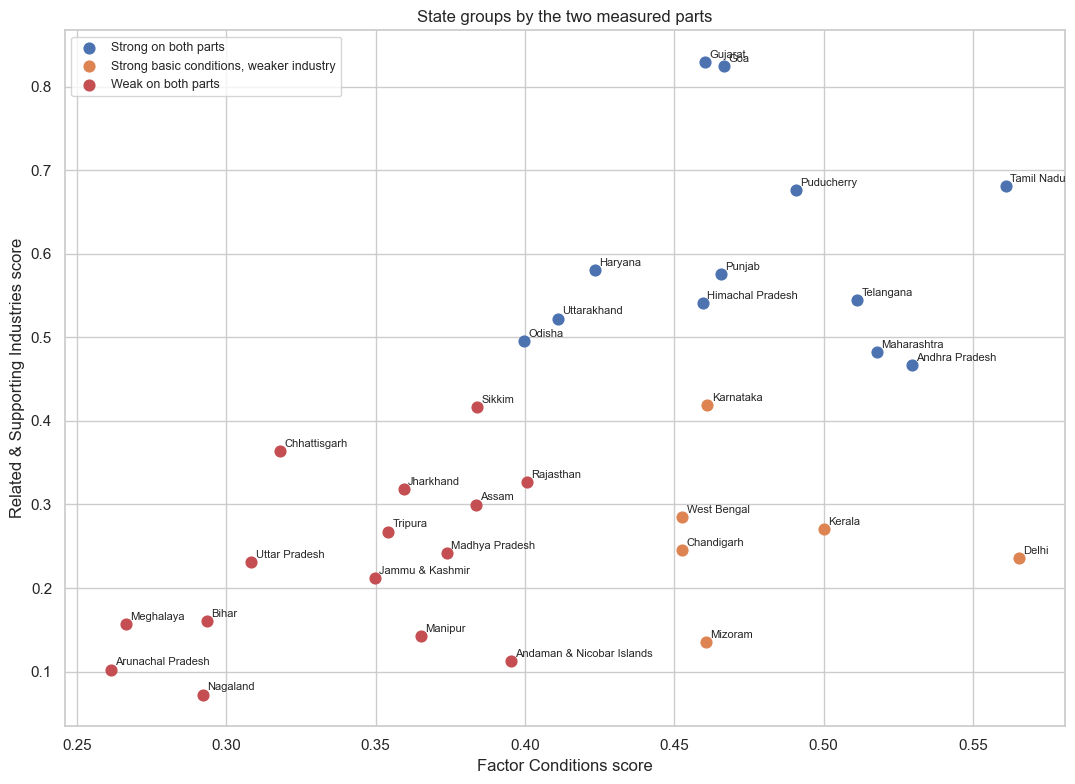

In [5]:
palette = {
    "Strong on both parts": "#4c72b0",
    "Strong basic conditions, weaker industry": "#dd8452",
    "Weak on both parts": "#c44e52",
}

plt.figure(figsize=(11, 8))
for nm in order:
    pts = X[cluster_name == nm]
    plt.scatter(pts["factor_conditions"], pts["related_supporting"],
                s=60, color=palette[nm], label=nm)
    for state, row in pts.iterrows():
        plt.annotate(state, (row["factor_conditions"], row["related_supporting"]),
                     fontsize=8, xytext=(3, 3), textcoords="offset points")

plt.xlabel("Factor Conditions score")
plt.ylabel("Related & Supporting Industries score")
plt.title("State groups by the two measured parts")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(fig_dir / "state_clusters.png", dpi=150)
plt.show()

In [6]:
cluster_name.to_frame("cluster").to_csv(reports_dir / "state_clusters.csv", index_label="state")
print("saved:", reports_dir / "state_clusters.csv")

saved: D:\india-state-competitiveness-index\version2\reports\state_clusters.csv
